In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Cleaning

In [3]:
geo = pd.read_csv('../data/Zambia_Geographic/geo_natural_resource.csv')

In [4]:
geo_clean, geo_lookup = clean_wb_wide(geo, drop_top_rows=0)

In [5]:
print(
    make_lookup_latex(
        geo_lookup,
        caption='World Bank indicators used in Geographic and Natural Resource Analysis',
        label='tab:geo_indicator_list'
    )
)

\begin{table}
\caption{World Bank indicators used in Geographic and Natural Resource Analysis}
\label{tab:geo_indicator_list}
\begin{tabular}{lp{10cm}}
\toprule
Series Code & Series Name \\
\midrule
AG.LND.IRIG.AG.ZS & Agricultural irrigated land (\% of total agricultural land) \\
AG.LND.AGRI.ZS & Agricultural land (\% of land area) \\
ER.H2O.FWTL.ZS & Annual freshwater withdrawals, total (\% of internal resources) \\
AG.LND.ARBL.ZS & Arable land (\% of land area) \\
NY.GDP.COAL.RT.ZS & Coal rents (\% of GDP) \\
EN.CLC.MDAT.ZS & Droughts, floods, extreme temperatures (\% of population, average 1990-2009) \\
AG.LND.FRST.ZS & Forest area (\% of land area) \\
NY.GDP.FRST.RT.ZS & Forest rents (\% of GDP) \\
VC.IDP.NWDS & Internally displaced persons, new displacement associated with disasters (number of cases) \\
ER.H2O.FWST.ZS & Level of water stress: freshwater withdrawal as a proportion of available freshwater resources \\
NY.GDP.MINR.RT.ZS & Mineral rents (\% of GDP) \\
NY.GDP.NGAS.RT.

In [7]:
# Observed Seasonal Cycle
OSC_1901_1930 = pd.read_csv('../data/Zambia_Geographic/Observed Seasonal Cycle_1901-1930.csv')
OSC_1931_1960 = pd.read_csv('../data/Zambia_Geographic/Observed Seasonal Cycle_1931-1960.csv')
OSC_1961_1990 = pd.read_csv('../data/Zambia_Geographic/Observed Seasonal Cycle_1961-1990.csv')
OSC_1991_2020 = pd.read_csv('../data/Zambia_Geographic/Observed Seasonal Cycle_1991-2020.csv')

Each oberserved seasonal cycle contains 30 years average of monthly temperature and rainfall data.

In [8]:
def clean_osc(df, period):
    df = df.copy()

    # Rename columns (short + consistent)
    df = df.rename(columns={
        'Category': 'Month',
        'Average Minimum Surface Air Temperature (°C)': 'tasmin',
        'Average Mean Surface Air Temperature (°C)': 'tas',
        'Average Maximum Surface Air Temperature (°C)': 'tasmax',
        'Precipitation (mm)': 'pr'
    })

    # Add period label
    df['Period'] = period

    return df

In [11]:
osc1 = clean_osc(OSC_1901_1930, '1901-1930')
osc2 = clean_osc(OSC_1931_1960, '1931-1960')
osc3 = clean_osc(OSC_1961_1990, '1961-1990')
osc4 = clean_osc(OSC_1991_2020, '1991-2020')
osc_all = pd.concat([osc1, osc2, osc3, osc4], ignore_index=True)

In [12]:
osc_all

,Month,tasmin,tas,tasmax,pr,Period
0,Jan,17.87,22.97,28.13,225.03,1901-1930
1,Feb,17.74,22.97,28.25,205.38,1901-1930
2,Mar,17.28,22.79,28.36,165.64,1901-1930
3,Apr,15.46,21.88,28.35,38.98,1901-1930
4,May,11.88,19.51,27.20,6.05,1901-1930
5,Jun,9.14,17.50,25.91,0.40,1901-1930
6,Jul,8.39,16.92,25.50,0.10,1901-1930
7,Aug,10.61,19.16,27.76,0.14,1901-1930
8,Sep,14.27,22.66,31.10,2.47,1901-1930
9,Oct,17.27,24.82,32.42,22.82,1901-1930


# Check data availability

In [5]:
geo_summary = summary_wb(geo_clean, geo_lookup)
geo_summary

,Series Code,Series Name,missing_pct,n_obs,first_year,last_year
0,AG.LND.IRIG.AG.ZS,Agricultural irrigated land (% of total agricu...,100.000000,0,NaN,NaN
1,AG.LND.AGRI.ZS,Agricultural land (% of land area),3.076923,63,1961.0,2023.0
2,ER.H2O.FWTL.ZS,"Annual freshwater withdrawals, total (% of int...",52.307692,31,1992.0,2022.0
3,AG.LND.ARBL.ZS,Arable land (% of land area),3.076923,63,1961.0,2023.0
4,NY.GDP.COAL.RT.ZS,Coal rents (% of GDP),21.538462,51,1971.0,2021.0
5,EN.CLC.MDAT.ZS,"Droughts, floods, extreme temperatures (% of p...",98.461538,1,2009.0,2009.0
6,AG.LND.FRST.ZS,Forest area (% of land area),47.692308,34,1990.0,2023.0
7,NY.GDP.FRST.RT.ZS,Forest rents (% of GDP),20.000000,52,1970.0,2021.0
8,VC.IDP.NWDS,"Internally displaced persons, new displacement...",80.000000,13,2008.0,2023.0
9,ER.H2O.FWST.ZS,Level of water stress: freshwater withdrawal a...,52.307692,31,1992.0,2022.0


In [6]:
print(
    make_summary_latex(
    geo_summary,
    caption='Data availability of Geographic and Natural Resource Analysis (Zambia)',
    label='tab:geo_data_availability')
)

\begin{table}
\caption{Data availability of Geographic and Natural Resource Analysis (Zambia)}
\label{tab:geo_data_availability}
\begin{tabular}{lrrrr}
\toprule
Series Code & Missing (\textbackslash \%) & Obs. & First year & Last year \\
\midrule
AG.LND.IRIG.AG.ZS & 100.00 & 0 & NaN & NaN \\
AG.LND.AGRI.ZS & 3.10 & 63 & 1961.00 & 2023.00 \\
ER.H2O.FWTL.ZS & 52.30 & 31 & 1992.00 & 2022.00 \\
AG.LND.ARBL.ZS & 3.10 & 63 & 1961.00 & 2023.00 \\
NY.GDP.COAL.RT.ZS & 21.50 & 51 & 1971.00 & 2021.00 \\
EN.CLC.MDAT.ZS & 98.50 & 1 & 2009.00 & 2009.00 \\
AG.LND.FRST.ZS & 47.70 & 34 & 1990.00 & 2023.00 \\
NY.GDP.FRST.RT.ZS & 20.00 & 52 & 1970.00 & 2021.00 \\
VC.IDP.NWDS & 80.00 & 13 & 2008.00 & 2023.00 \\
ER.H2O.FWST.ZS & 52.30 & 31 & 1992.00 & 2022.00 \\
NY.GDP.MINR.RT.ZS & 20.00 & 52 & 1970.00 & 2021.00 \\
NY.GDP.NGAS.RT.ZS & 21.50 & 51 & 1971.00 & 2021.00 \\
NY.GDP.PETR.RT.ZS & 21.50 & 51 & 1971.00 & 2021.00 \\
ER.H2O.INTR.PC & 4.60 & 62 & 1961.00 & 2022.00 \\
ER.H2O.INTR.K3 & 4.60 & 62 & 1961.00

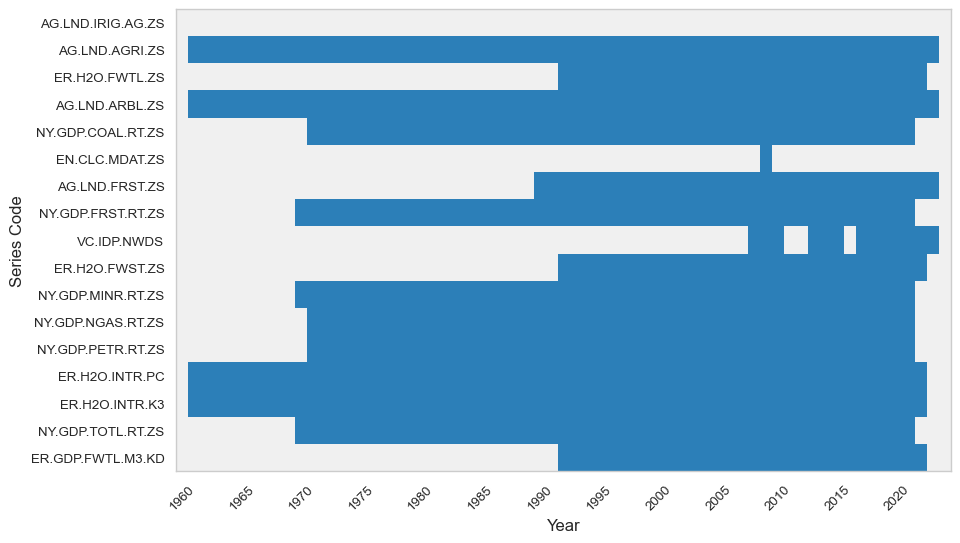

In [7]:
availability, fig, ax = plot_missing_heatmap(
    geo_clean,
    lookup=geo_lookup
)

fig.savefig('../figures/Zambia/geographic/geo_data_availability.png', bbox_inches='tight')

# Data Visualization

In [8]:
geo_lookup

,Series Code,Series Name
0,AG.LND.IRIG.AG.ZS,Agricultural irrigated land (% of total agricu...
1,AG.LND.AGRI.ZS,Agricultural land (% of land area)
2,ER.H2O.FWTL.ZS,"Annual freshwater withdrawals, total (% of int..."
3,AG.LND.ARBL.ZS,Arable land (% of land area)
4,NY.GDP.COAL.RT.ZS,Coal rents (% of GDP)
5,EN.CLC.MDAT.ZS,"Droughts, floods, extreme temperatures (% of p..."
6,AG.LND.FRST.ZS,Forest area (% of land area)
7,NY.GDP.FRST.RT.ZS,Forest rents (% of GDP)
8,VC.IDP.NWDS,"Internally displaced persons, new displacement..."
9,ER.H2O.FWST.ZS,Level of water stress: freshwater withdrawal a...


## Geographic and Climate Measures

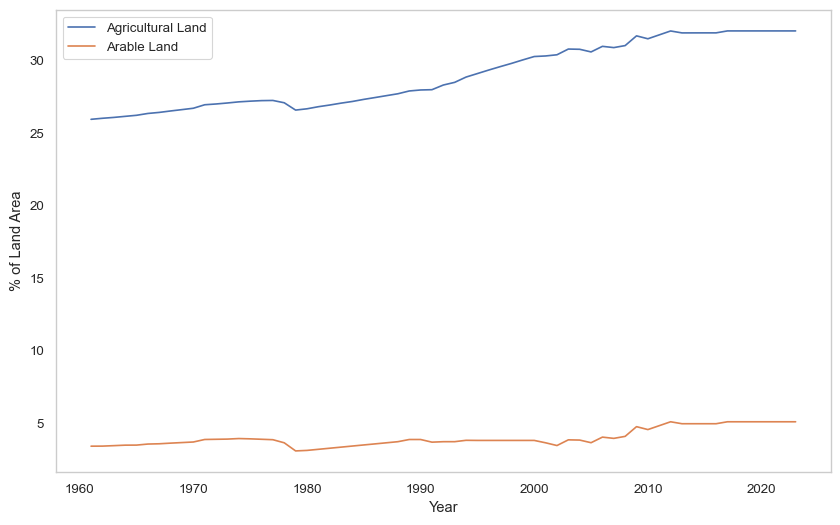

In [19]:
# percentage of arable land
df = geo_clean.dropna(subset=['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS'])
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['Year'], df['AG.LND.AGRI.ZS'], label= 'Agricultural Land')
ax.plot(df['Year'], df['AG.LND.ARBL.ZS'], label= 'Arable Land')

ax.set_xlabel('Year')
ax.set_ylabel('% of Land Area')
ax.legend()
ax.grid(False)

In [22]:
# Show range, average, and std of arable land and agricultural land by statistic table
df = geo_clean.dropna(subset=['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS'])
df[['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS']].describe()

print(
    make_summary_latex(
    df[['AG.LND.AGRI.ZS','AG.LND.ARBL.ZS']].describe().T,
    caption='Summary statistics of Agricultural Land and Arable Land (% of land area)',
    label='tab:land_summary')
)

\begin{table}
\caption{Summary statistics of Agricultural Land and Arable Land (% of land area)}
\label{tab:land_summary}
\begin{tabular}{rrrrrrrr}
\toprule
count & mean & std & min & 25\% & 50\% & 75\% & max \\
\midrule
63.00 & 28.97 & 2.20 & 25.97 & 27.06 & 28.34 & 31.03 & 32.07 \\
63.00 & 4.00 & 0.60 & 3.10 & 3.62 & 3.83 & 4.08 & 5.11 \\
\bottomrule
\end{tabular}
\end{table}



In [27]:
# data on climate such as temperature, rainfall etc (long-term averages)
df = geo_clean.dropna(subset = ['EN.CLC.MDAT.ZS'])
df['EN.CLC.MDAT.ZS'] # Droughts, floods, extreme temperatures (% of population, average 1990-2009)

49    4.199677
Name: EN.CLC.MDAT.ZS, dtype: float64

Check more temperature and rainfall data on:
https://climateknowledgeportal.worldbank.org/country/zambia/climate-data-historical

In [17]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

osc_all['Month'] = pd.Categorical(
    osc_all['Month'],
    categories=month_order,
    ordered=True
)

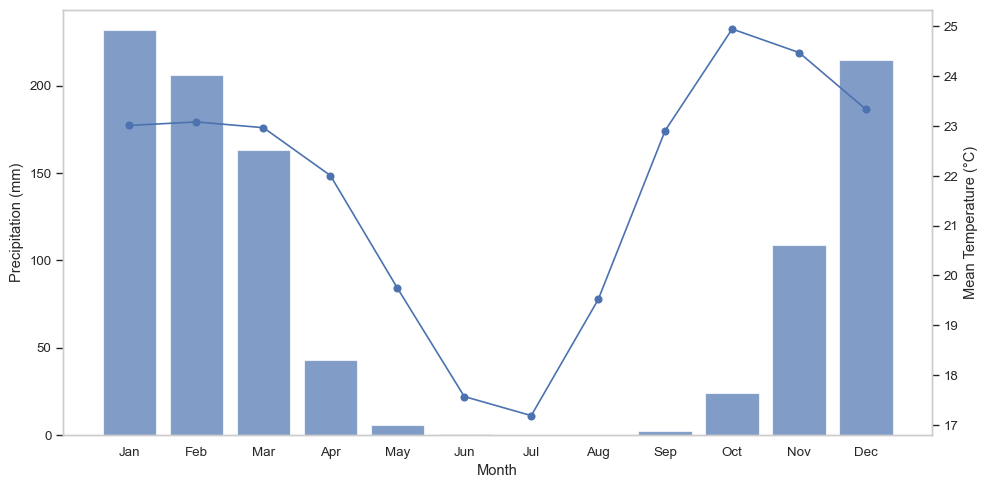

In [18]:
# Average Overall Observed Seasonal Cycle
osc_avg = (
    osc_all.groupby('Month', observed=True)[['tas', 'tasmin', 'tasmax', 'pr']]
    .mean()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(osc_avg['Month'], osc_avg['pr'], alpha=0.7)
ax1.set_ylabel('Precipitation (mm)')
ax1.set_xlabel('Month')

ax2 = ax1.twinx()
ax2.plot(osc_avg['Month'], osc_avg['tas'], marker='o')
ax2.set_ylabel('Mean Temperature (°C)')

ax1.grid(False)
ax2.grid(False)

plt.tight_layout()
plt.show()

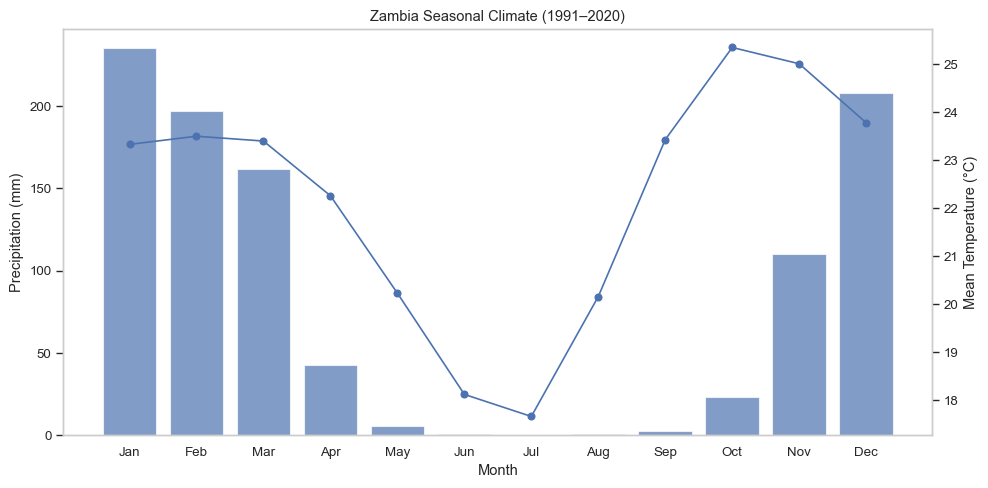

In [20]:
# Recent Observed Seasonal Cycle (1991-2020)
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(osc4['Month'], osc4['pr'], alpha=0.7)
ax1.set_ylabel('Precipitation (mm)')
ax1.set_xlabel('Month')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(osc4['Month'], osc4['tas'], marker='o')
ax2.set_ylabel('Mean Temperature (°C)')
ax2.grid(False)

plt.title('Zambia Seasonal Climate (1991–2020)')
plt.tight_layout()
plt.show()

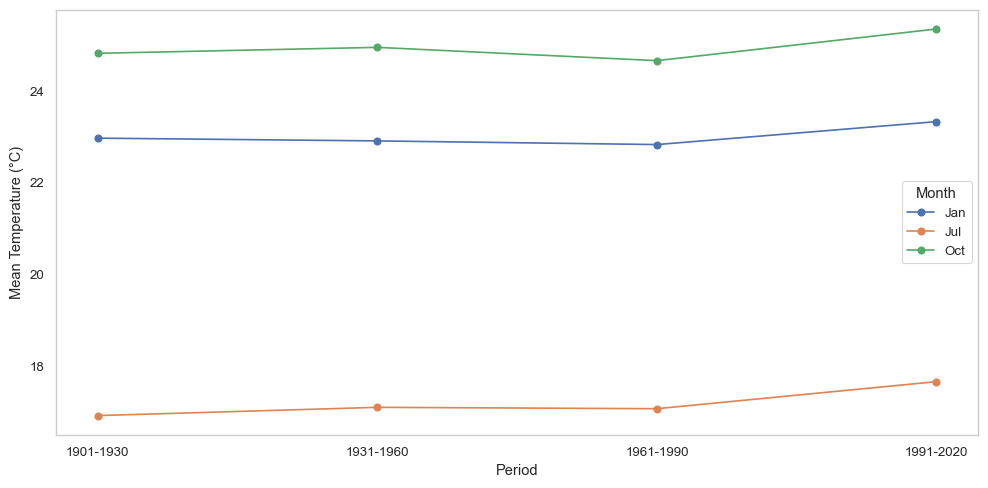

In [22]:
# period-to-period comparison: Temperature
selected_months = ['Jan', 'Jul', 'Oct']
osc_sel = osc_all[osc_all['Month'].isin(selected_months)]

fig, ax = plt.subplots(figsize=(10, 5))

for month in selected_months:
    temp_data = osc_sel[osc_sel['Month'] == month]
    ax.plot(temp_data['Period'], temp_data['tas'], marker='o', label=month)

ax.set_xlabel('Period')
ax.set_ylabel('Mean Temperature (°C)')
ax.grid(False)

ax.legend(title='Month')
plt.tight_layout()
plt.show()

In [27]:
pivot_temp = osc_all.pivot(index='Month', columns='Period', values='tas')

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

pivot_temp = pivot_temp.loc[month_order]

pivot_temp['Difference (1901-1930 with 1991-2020)'] = (
    pivot_temp['1991-2020'] - pivot_temp['1901-1930']
)
pivot_temp

Period,1901-1930,1931-1960,1961-1990,1991-2020,Difference (1901-1930 with 1991-2020)
Month,,,,,
Jan,22.97,22.91,22.83,23.33,0.36
Feb,22.97,22.96,22.89,23.50,0.53
Mar,22.79,22.83,22.84,23.40,0.61
Apr,21.88,22.02,21.86,22.26,0.38
May,19.51,19.72,19.53,20.23,0.72
Jun,17.50,17.35,17.31,18.12,0.62
Jul,16.92,17.10,17.07,17.66,0.74
Aug,19.16,19.32,19.43,20.16,1.00
Sep,22.66,22.69,22.85,23.43,0.77


In [31]:
pivot_pr = osc_all.pivot(index='Month', columns='Period', values='pr')
pivot_pr = pivot_pr.loc[month_order]

pivot_pr['Difference (1901-1930 with 1991-2020)'] = (
    pivot_pr['1991-2020'] - pivot_pr['1901-1930']
)
pivot_pr

Period,1901-1930,1931-1960,1961-1990,1991-2020,Difference (1901-1930 with 1991-2020)
Month,,,,,
Jan,225.03,235.98,231.36,235.23,10.20
Feb,205.38,216.55,205.61,197.02,-8.36
Mar,165.64,164.82,159.83,161.99,-3.65
Apr,38.98,40.70,49.95,42.84,3.86
May,6.05,5.56,6.09,5.72,-0.33
Jun,0.40,0.53,0.59,0.49,0.09
Jul,0.10,0.08,0.13,0.18,0.08
Aug,0.14,0.22,0.26,0.26,0.12
Sep,2.47,1.96,3.03,2.64,0.17


In [32]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Precipitation
pivot_pr = osc_all.pivot(index='Month', columns='Period', values='pr')
pivot_pr = pivot_pr.loc[month_order]
pivot_pr['diff_pr'] = pivot_pr['1991-2020'] - pivot_pr['1901-1930']

# Temperature
pivot_temp = osc_all.pivot(index='Month', columns='Period', values='tas')
pivot_temp = pivot_temp.loc[month_order]
pivot_temp['diff_tas'] = pivot_temp['1991-2020'] - pivot_temp['1901-1930']

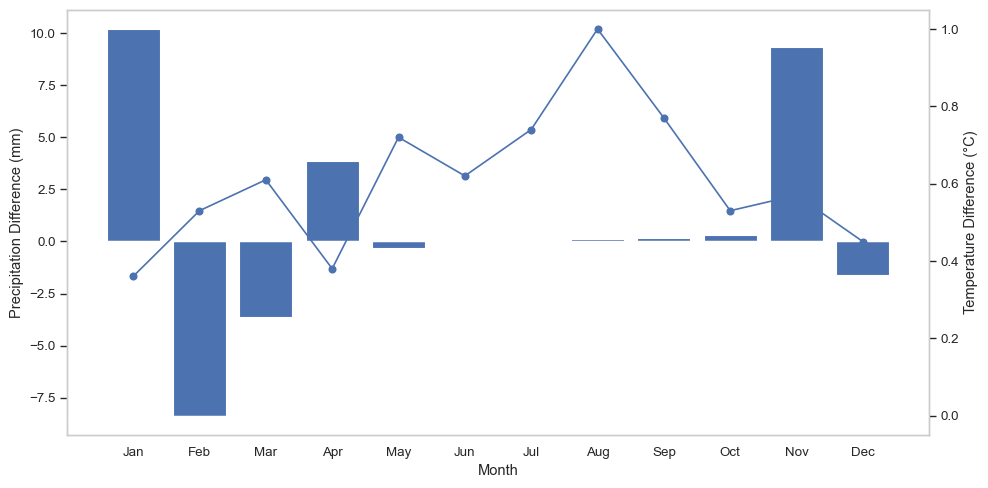

In [36]:
# Monthly Precipitation Difference: 1991–2020 vs 1901–1930

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(pivot_pr.index, pivot_pr['diff_pr'])
ax1.axhline(0, linewidth=1)
ax1.set_xlabel('Month')
ax1.set_ylabel('Precipitation Difference (mm)')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(pivot_temp.index, pivot_temp['diff_tas'], marker='o')
ax2.axhline(0, linewidth=1)
ax2.set_xlabel('Month')
ax2.set_ylabel('Temperature Difference (°C)')
ax2.grid(False)

plt.tight_layout()
plt.show()

## Natural Resource Measures

In [ ]:
# oil rents as % of GDP


In [ ]:
# natural gas rents as % of GDP